In [3]:
# 셀 1: 라이브러리 및 시각화 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 셀 2: 데이터 로드 및 기본 전처리
df = pd.read_csv('./data/train_merged.csv')

# 이전 EDA에서 진행했던 컬럼 정리 및 피처 생성
df.rename(columns={'TestDate_x': 'TestDate', 'Test_x': 'Test'}, inplace=True)
df.drop(columns=['Test_y'], inplace=True)

def age_to_numeric(age):
    if isinstance(age, str):
        decade = int(age[:-1])
        return decade + 2 if age[-1] == 'a' else decade + 7
    return age

df['Age_numeric'] = df['Age'].apply(age_to_numeric)
df['TestYear'] = df['TestDate'].astype(str).str[:4]
df['TestMonth'] = df['TestDate'].astype(str).str[4:]

print("데이터 준비 완료. 상위 5개 데이터:")
display(df.head())

C:\Users\정주환\AppData\Local\Temp\ipykernel_27808\4217469871.py:2: DtypeWarning: Columns (5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/train_merged.csv')


데이터 준비 완료. 상위 5개 데이터:


,Test_id,Test,PrimaryKey,Age,TestDate,A1-1,A1-2,A1-3,A1-4,A2-1,...,B10-1,B10-2,B10-3,B10-4,B10-5,B10-6,Label,Age_numeric,TestYear,TestMonth
0,0x744773A3B58E27F1811B47B53331F272AB5E569A9F72...,A,0x744773A3B58E27F1811B47B53331F272AB5E569A9F72...,20a,201811,"2,2,1,2,1,2,1,1,2,1,2,1,1,2,1,2,2,1","1,3,3,2,3,3,2,2,3,3,2,1,2,1,1,1,2,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","29,33,56,64,5,-51,44,-1,0,31,30,5,67,33,43,21,...","1,1,2,3,1,2,2,3,3,1,1,3,2,2,1,2,3,3",...,NaN,NaN,NaN,NaN,NaN,NaN,0,22,2018,11
1,0xDA7DE599194F2B4F9624ACBCE96E66E2F8B357A4DD97...,A,0xDA7DE599194F2B4F9624ACBCE96E66E2F8B357A4DD97...,20a,201811,"2,2,1,2,2,1,1,1,2,2,1,2,1,1,2,1,2,1","3,2,2,1,1,3,1,1,2,3,2,1,3,1,2,3,3,2","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","76,1,27,25,41,34,-24,7,18,85,-18,-21,31,-7,18,...","2,3,3,1,2,2,3,2,3,1,2,3,1,3,2,1,1,1",...,NaN,NaN,NaN,NaN,NaN,NaN,0,22,2018,11
2,0x7DF700D37380AD164ADF79B485C3A84A571186E3DB27...,A,0x7DF700D37380AD164ADF79B485C3A84A571186E3DB27...,20a,201802,"1,1,2,1,2,2,2,2,1,2,1,1,1,1,1,2,2,2","2,3,3,1,1,2,1,1,3,2,1,2,2,3,1,2,3,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-1,22,0,-37,-21,7,-34,-21,-79,-26,-80,-23,-63,...","1,1,3,2,3,2,1,1,1,1,3,2,2,2,2,3,3,3",...,NaN,NaN,NaN,NaN,NaN,NaN,0,22,2018,02
3,0xAB057D1B8C3A8FB6E99F1B6E0F95086150951BCA8630...,A,0xAB057D1B8C3A8FB6E99F1B6E0F95086150951BCA8630...,20a,201805,"2,2,2,2,1,2,1,1,2,2,1,1,1,1,2,1,2,1","1,3,3,1,2,2,2,3,2,3,2,1,1,1,2,3,1,3","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0","-60,25,-25,-34,-40,-60,-46,-79,-77,-51,-80,-62...","1,2,2,3,1,1,2,2,3,1,3,2,1,3,3,3,2,1",...,NaN,NaN,NaN,NaN,NaN,NaN,0,22,2018,05
4,0xAD4EC2C13080BC51C988805376AB404CCD2BA53CB108...,A,0xAD4EC2C13080BC51C988805376AB404CCD2BA53CB108...,20a,201806,"2,2,1,1,2,1,1,2,1,1,1,1,2,2,1,2,2,2","1,3,1,3,2,1,1,1,3,2,2,2,2,3,3,3,2,1","0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0","-42,-77,-33,-3,-38,-58,-88,-4,-28,-58,-40,-29,...","1,3,3,2,2,2,3,1,3,1,1,2,1,3,1,2,3,2",...,NaN,NaN,NaN,NaN,NaN,NaN,0,22,2018,06


In [5]:
# 셀 3: 운전자별 검사 횟수 계산 및 데이터프레임에 추가
test_counts = df['PrimaryKey'].value_counts()
df['TestCount'] = df['PrimaryKey'].map(test_counts)

print("--- 운전자별 검사 횟수 분포 ---")
display(df['TestCount'].describe())

--- 운전자별 검사 횟수 분포 ---


count    944767.000000
mean          1.529942
std           0.983240
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          10.000000
Name: TestCount, dtype: float64

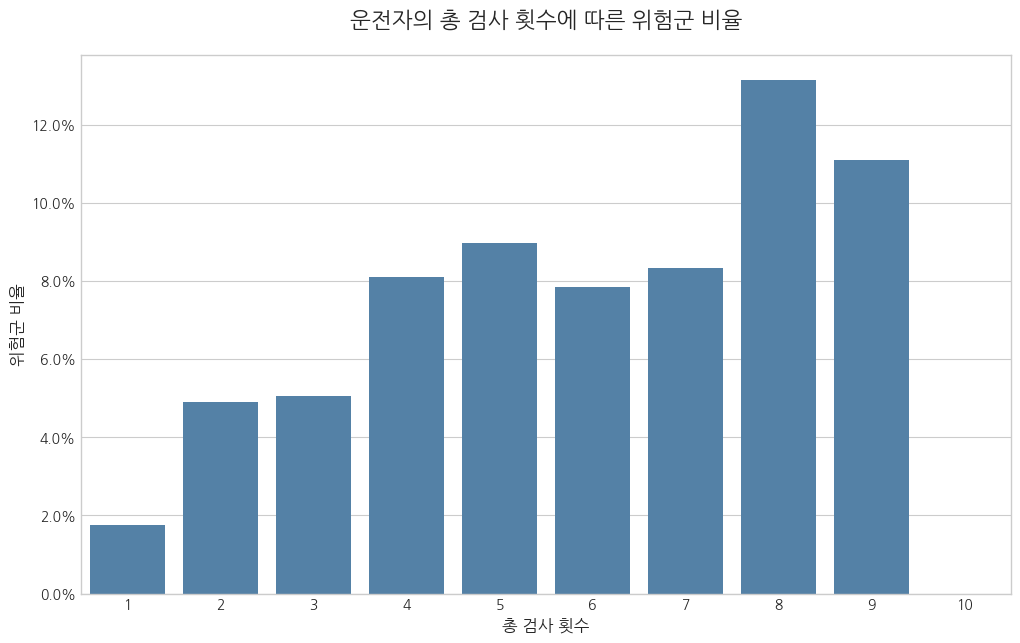

In [6]:
# 셀 4: 검사 횟수에 따른 위험군 비율 분석
# 검사 횟수별로 그룹화하여 Label의 평균(위험군 비율)을 계산합니다.
test_count_risk = df.groupby('TestCount')['Label'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='TestCount', y='Label', data=test_count_risk, color='steelblue')

plt.title('운전자의 총 검사 횟수에 따른 위험군 비율', fontsize=16, pad=20)
plt.xlabel('총 검사 횟수', fontsize=12)
plt.ylabel('위험군 비율', fontsize=12)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1%}')) # Y축을 퍼센트로 표시

plt.show()

C:\Users\정주환\AppData\Local\Temp\ipykernel_27808\4132226735.py:2: FutureWarning: The provided callable <function mean at 0x000001B3FEE50900> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = df.pivot_table(values='Label', index='Age_numeric', columns='Test', aggfunc=np.mean)


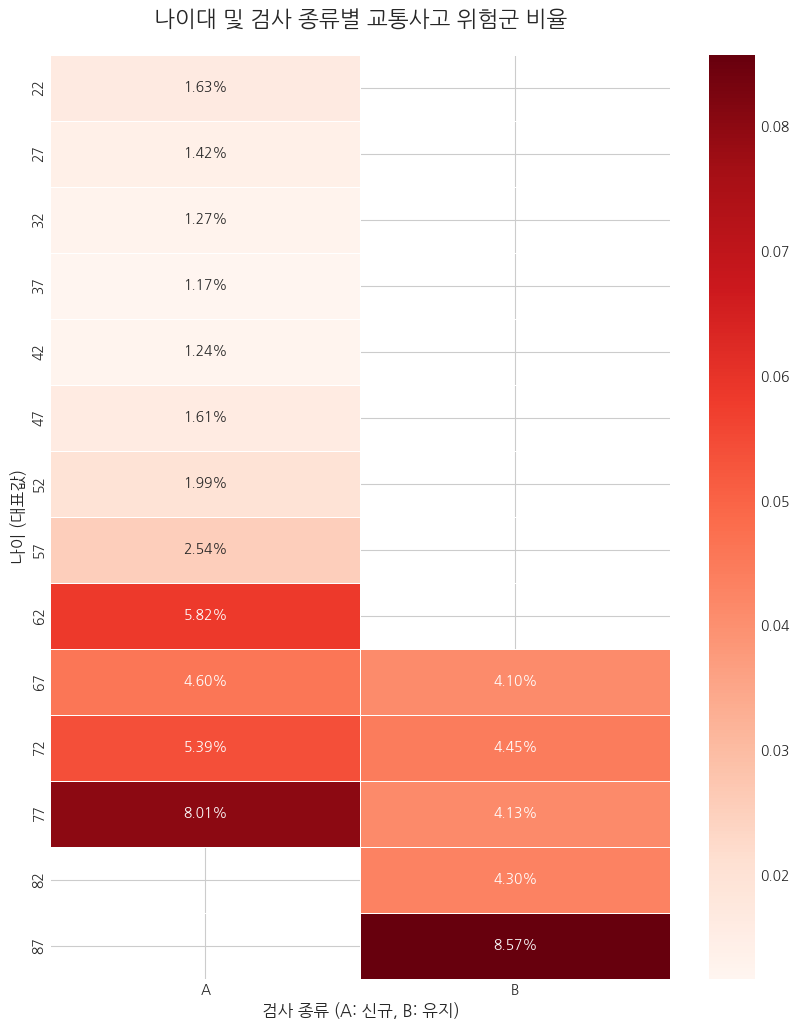

In [7]:
# 셀 5: 나이와 검사 종류를 결합한 위험군 비율 분석 (Pivot Table & Heatmap)
pivot_table = df.pivot_table(values='Label', index='Age_numeric', columns='Test', aggfunc=np.mean)

plt.figure(figsize=(10, 12))
sns.heatmap(pivot_table, annot=True, fmt='.2%', cmap='Reds', linewidths=.5)

plt.title('나이대 및 검사 종류별 교통사고 위험군 비율', fontsize=16, pad=20)
plt.xlabel('검사 종류 (A: 신규, B: 유지)', fontsize=12)
plt.ylabel('나이 (대표값)', fontsize=12)
plt.show()

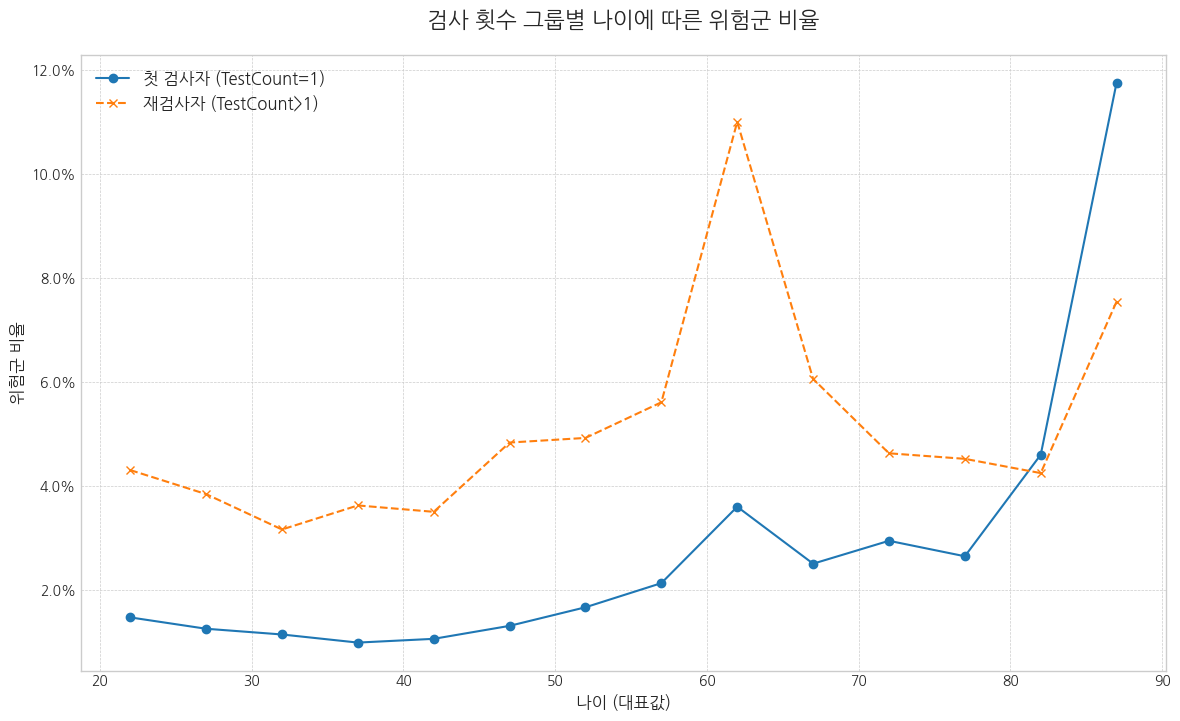

In [8]:
# 셀 6: 첫 검사자(TestCount=1) 그룹과 재검사자(TestCount>1) 그룹 분리
first_timers = df[df['TestCount'] == 1]
repeaters = df[df['TestCount'] > 1]

# 각 그룹에서 나이대별 위험군 비율 계산
first_timer_risk = first_timers.groupby('Age_numeric')['Label'].mean()
repeater_risk = repeaters.groupby('Age_numeric')['Label'].mean()

plt.figure(figsize=(14, 8))
plt.plot(first_timer_risk.index, first_timer_risk.values, marker='o', linestyle='-', label='첫 검사자 (TestCount=1)')
plt.plot(repeater_risk.index, repeater_risk.values, marker='x', linestyle='--', label='재검사자 (TestCount>1)')

plt.title('검사 횟수 그룹별 나이에 따른 위험군 비율', fontsize=16, pad=20)
plt.xlabel('나이 (대표값)', fontsize=12)
plt.ylabel('위험군 비율', fontsize=12)
plt.legend(fontsize=12)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.1%}'))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

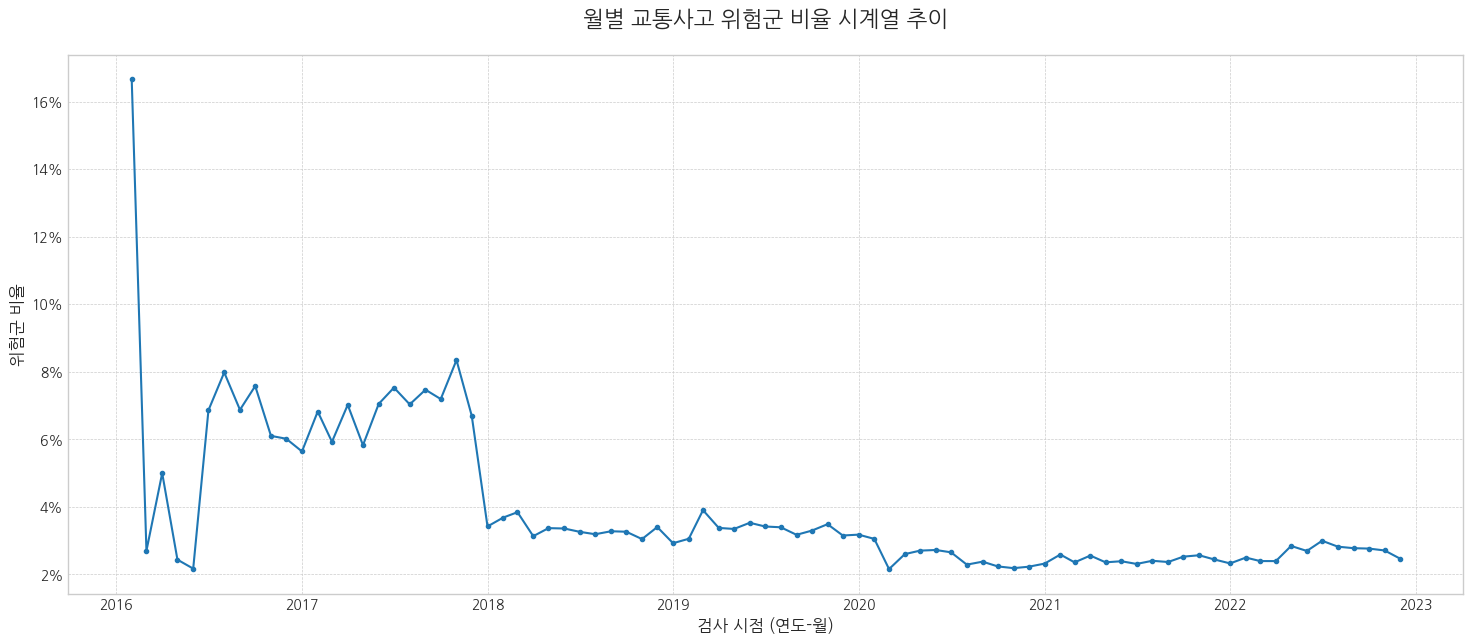

In [9]:
# 셀 7: 연도-월별 위험군 비율 시계열 분석
# yyyymm 형식의 'TestDate'를 시계열 분석에 용이하게 datetime 객체로 변환
df['Date'] = pd.to_datetime(df['TestDate'], format='%Y%m')

# 월별로 그룹화하여 위험군 비율 계산
monthly_risk = df.groupby('Date')['Label'].mean().reset_index()

plt.figure(figsize=(18, 7))
plt.plot(monthly_risk['Date'], monthly_risk['Label'], marker='.', linestyle='-')

plt.title('월별 교통사고 위험군 비율 시계열 추이', fontsize=16, pad=20)
plt.xlabel('검사 시점 (연도-월)', fontsize=12)
plt.ylabel('위험군 비율', fontsize=12)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [10]:
#분석 대상 데이터 준비 (Test B, 60세 이상)
# df에 Age_numeric 피처가 이미 생성되어 있다고 가정합니다.
senior_B = df[(df['Test'] == 'B') & (df['Age_numeric'] >= 60)].copy()

# 위험군과 비위험군으로 분리
risky_senior_B = senior_B[senior_B['Label'] == 1]
safe_senior_B = senior_B[senior_B['Label'] == 0]

print(f"분석 대상: 60세 이상 Test B 응시자 {len(senior_B)}명")
print(f"┣━ 위험군(Label=1): {len(risky_senior_B)}명")
print(f"┗━ 비위험군(Label=0): {len(safe_senior_B)}명")

분석 대상: 60세 이상 Test B 응시자 297526명
┣━ 위험군(Label=1): 12590명
┗━ 비위험군(Label=0): 284936명


C:\Users\정주환\AppData\Local\Temp\ipykernel_27808\4261465541.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  risky_senior_B[col] = pd.to_numeric(risky_senior_B[col], errors='coerce')
C:\Users\정주환\AppData\Local\Temp\ipykernel_27808\4261465541.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  safe_senior_B[col] = pd.to_numeric(safe_senior_B[col], errors='coerce')


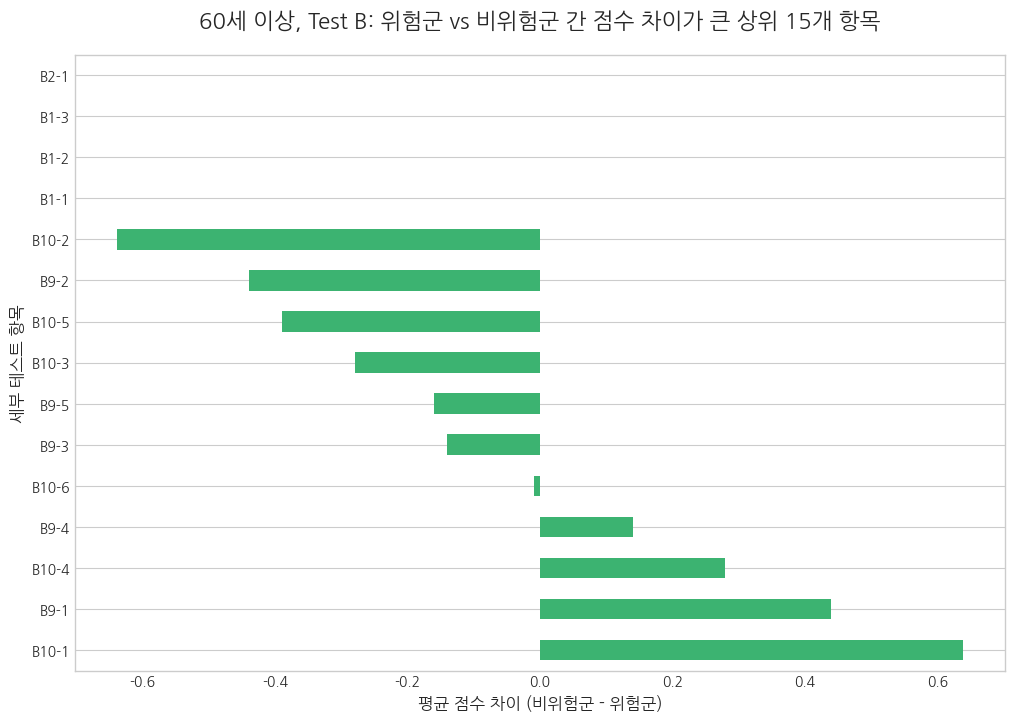

In [11]:
# 고령 운전자(Test B) 위험군 vs 비위험군 점수 차이 분석

# B로 시작하는 세부 항목 컬럼 이름만 추출합니다.
b_cols = [col for col in df.columns if col.startswith('B')]

# [해결 코드 추가!] B 항목 컬럼들을 강제로 숫자 타입으로 변환합니다.
# 숫자로 변환할 수 없는 값은 Na(결측치)로 처리됩니다.
for col in b_cols:
    risky_senior_B[col] = pd.to_numeric(risky_senior_B[col], errors='coerce')
    safe_senior_B[col] = pd.to_numeric(safe_senior_B[col], errors='coerce')

# --- 이하 코드는 기존과 동일 ---

# 각 그룹(위험군, 비위험군)의 세부 항목별 평균 점수를 계산합니다.
mean_scores_senior_B = pd.DataFrame({
    'Risky_Senior_Mean': risky_senior_B[b_cols].mean(),
    'Safe_Senior_Mean': safe_senior_B[b_cols].mean()
})

# '비위험군 평균'에서 '위험군 평균'을 빼서 점수 차이를 계산합니다.
mean_scores_senior_B['Difference'] = mean_scores_senior_B['Safe_Senior_Mean'] - mean_scores_senior_B['Risky_Senior_Mean']

# 계산된 점수 차이(Difference)를 기준으로 내림차순 정렬하고 상위 15개만 선택합니다.
top_diff_senior_B = mean_scores_senior_B.sort_values(by='Difference', ascending=False).head(15)

# 시각화를 위한 그래프 크기를 설정합니다.
plt.figure(figsize=(12, 8))

# 수평 막대 그래프(barh)로 시각화합니다.
top_diff_senior_B['Difference'].plot(kind='barh', color='mediumseagreen')

# 그래프의 제목과 축 레이블을 설정하여 가독성을 높입니다.
plt.title('60세 이상, Test B: 위험군 vs 비위험군 간 점수 차이가 큰 상위 15개 항목', fontsize=16, pad=20)
plt.xlabel('평균 점수 차이 (비위험군 - 위험군)', fontsize=12)
plt.ylabel('세부 테스트 항목', fontsize=12)

# 가로축에 그리드를 추가하여 값을 더 쉽게 읽을 수 있도록 합니다.
plt.grid(axis='x')

# 완성된 그래프를 출력합니다.
plt.show()

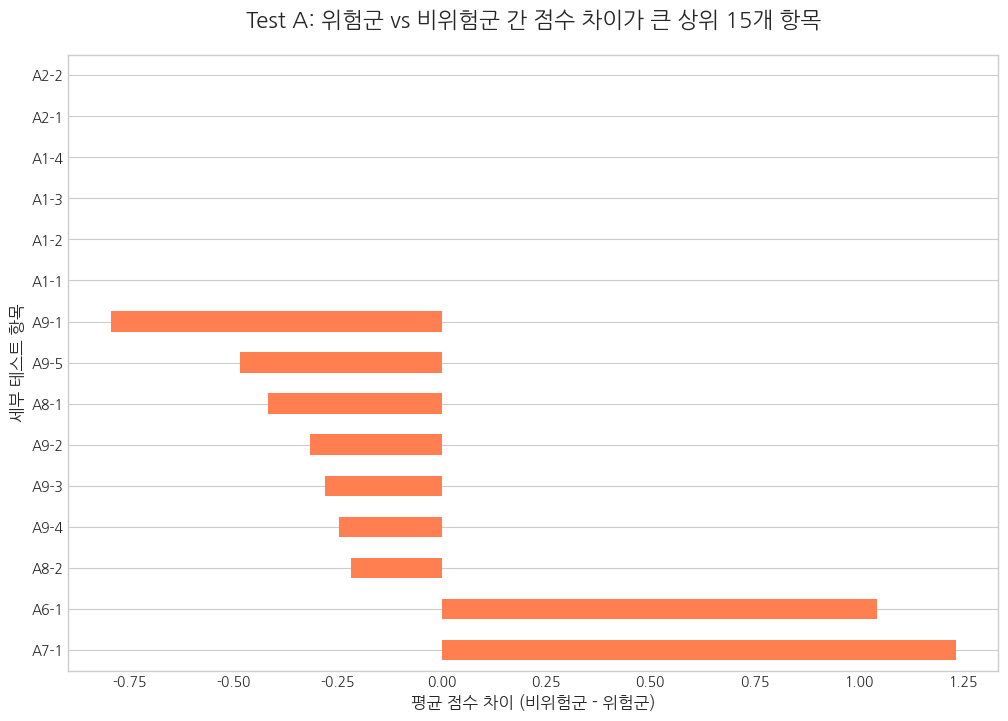

In [12]:
# 셀: [수정 완료] Test A 응시자의 약점 파악

# Test A 데이터만 필터링합니다.
df_A = df[df['Test'] == 'A'].copy()

# [수정된 부분!] 'A'로 시작하고, 두 번째 글자가 숫자인 컬럼만 선택합니다.
a_cols = [col for col in df_A.columns if col.startswith('A') and col[1].isdigit()]

# A 항목 컬럼들을 강제로 숫자 타입으로 변환합니다.
for col in a_cols:
    df_A[col] = pd.to_numeric(df_A[col], errors='coerce')

# 위험군(Label=1)과 비위험군(Label=0)으로 데이터를 분리합니다.
risky_A = df_A[df_A['Label'] == 1]
safe_A = df_A[df_A['Label'] == 0]

# 각 그룹의 세부 항목별 평균 점수를 계산합니다.
mean_scores_A = pd.DataFrame({
    'Risky_Group_Mean': risky_A[a_cols].mean(),
    'Safe_Group_Mean': safe_A[a_cols].mean()
})

# '비위험군 평균'에서 '위험군 평균'을 빼서 점수 차이를 계산합니다.
mean_scores_A['Difference'] = mean_scores_A['Safe_Group_Mean'] - mean_scores_A['Risky_Group_Mean']

# 점수 차이가 큰 순서대로 상위 15개 항목을 추출하여 시각화합니다.
top_diff_A = mean_scores_A.sort_values(by='Difference', ascending=False).head(15)

plt.figure(figsize=(12, 8))
top_diff_A['Difference'].plot(kind='barh', color='coral')
plt.title('Test A: 위험군 vs 비위험군 간 점수 차이가 큰 상위 15개 항목', fontsize=16, pad=20)
plt.xlabel('평균 점수 차이 (비위험군 - 위험군)', fontsize=12)
plt.ylabel('세부 테스트 항목', fontsize=12)
plt.grid(axis='x')
plt.show()

--- 신규 운전자 그룹(Test A) 평균 나이 비교 ---
위험군 평균 나이: 52.56세
비위험군 평균 나이: 46.67세
▶ 평균 나이 차이: -5.89세


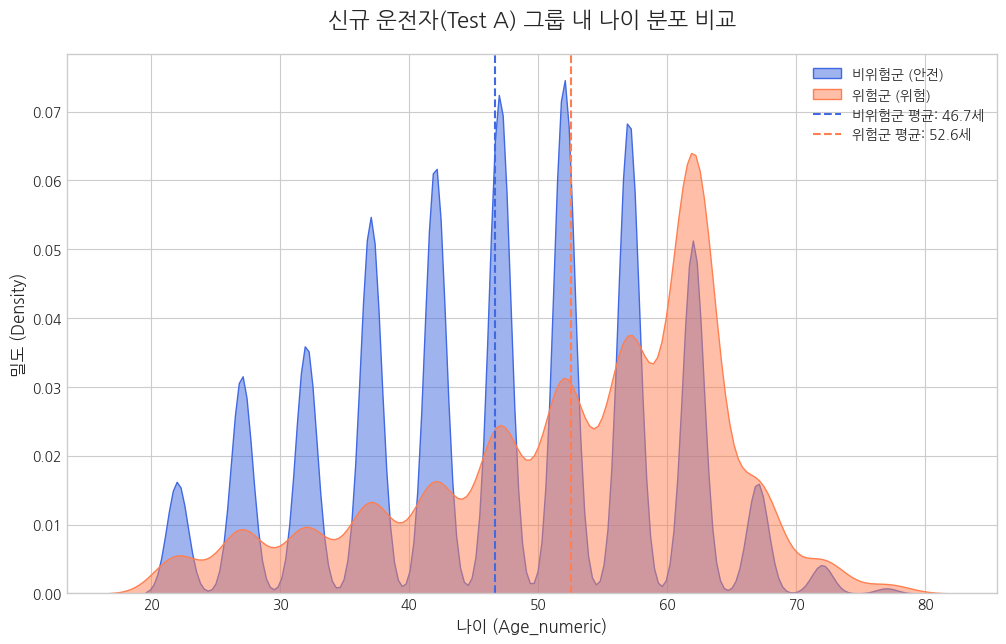

In [13]:
# 신규 운전자 그룹 내 나이 분포 비교

# Test A 데이터만 필터링합니다.
df_A = df[df['Test'] == 'A'].copy()

# 위험군(Label=1)과 비위험군(Label=0)으로 데이터를 분리합니다.
risky_A = df_A[df_A['Label'] == 1]
safe_A = df_A[df_A['Label'] == 0]

# 1. 수치로 평균 나이 차이 확인하기
risky_age_mean = risky_A['Age_numeric'].mean()
safe_age_mean = safe_A['Age_numeric'].mean()

print("--- 신규 운전자 그룹(Test A) 평균 나이 비교 ---")
print(f"위험군 평균 나이: {risky_age_mean:.2f}세")
print(f"비위험군 평균 나이: {safe_age_mean:.2f}세")
print(f"▶ 평균 나이 차이: {safe_age_mean - risky_age_mean:.2f}세")

# 2. 시각화로 분포 차이 확인하기 (KDE Plot)
plt.figure(figsize=(12, 7))
sns.kdeplot(data=safe_A['Age_numeric'], label='비위험군 (안전)', fill=True, alpha=0.5, color='royalblue')
sns.kdeplot(data=risky_A['Age_numeric'], label='위험군 (위험)', fill=True, alpha=0.5, color='coral')

# 각 그룹의 평균 나이를 수직선으로 표시
plt.axvline(safe_age_mean, color='royalblue', linestyle='--', label=f'비위험군 평균: {safe_age_mean:.1f}세')
plt.axvline(risky_age_mean, color='coral', linestyle='--', label=f'위험군 평균: {risky_age_mean:.1f}세')

plt.title('신규 운전자(Test A) 그룹 내 나이 분포 비교', fontsize=16, pad=20)
plt.xlabel('나이 (Age_numeric)', fontsize=12)
plt.ylabel('밀도 (Density)', fontsize=12)
plt.legend()
plt.show()

--- 자격 유지 검사(Test B) 그룹 평균 나이 비교 ---
위험군 평균 나이: 69.80세
비위험군 평균 나이: 69.72세
▶ 평균 나이 차이: 0.09세


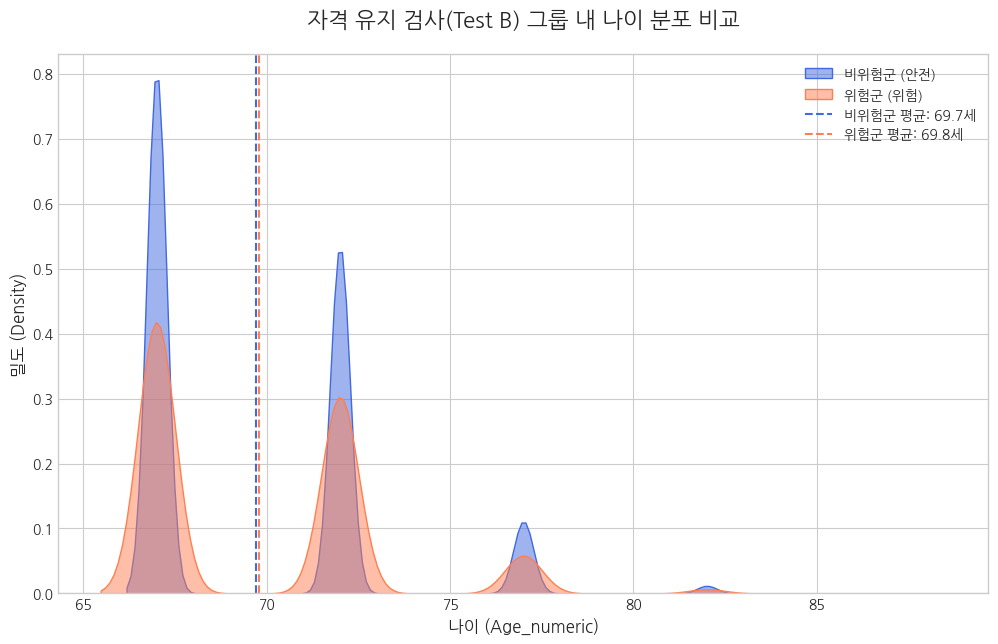

In [14]:
# 자격 유지 검사(Test B) 그룹 내 나이 분포 비교

# Test B 데이터만 필터링합니다.
df_B = df[df['Test'] == 'B'].copy()

# 위험군(Label=1)과 비위험군(Label=0)으로 데이터를 분리합니다.
risky_B = df_B[df_B['Label'] == 1]
safe_B = df_B[df_B['Label'] == 0]

# 1. 수치로 평균 나이 차이 확인하기
risky_age_mean_B = risky_B['Age_numeric'].mean()
safe_age_mean_B = safe_B['Age_numeric'].mean()

print("--- 자격 유지 검사(Test B) 그룹 평균 나이 비교 ---")
print(f"위험군 평균 나이: {risky_age_mean_B:.2f}세")
print(f"비위험군 평균 나이: {safe_age_mean_B:.2f}세")
print(f"▶ 평균 나이 차이: {risky_age_mean_B - safe_age_mean_B:.2f}세")

# 2. 시각화로 분포 차이 확인하기 (KDE Plot)
plt.figure(figsize=(12, 7))
sns.kdeplot(data=safe_B['Age_numeric'], label='비위험군 (안전)', fill=True, alpha=0.5, color='royalblue')
sns.kdeplot(data=risky_B['Age_numeric'], label='위험군 (위험)', fill=True, alpha=0.5, color='coral')

# 각 그룹의 평균 나이를 수직선으로 표시
plt.axvline(safe_age_mean_B, color='royalblue', linestyle='--', label=f'비위험군 평균: {safe_age_mean_B:.1f}세')
plt.axvline(risky_age_mean_B, color='coral', linestyle='--', label=f'위험군 평균: {risky_age_mean_B:.1f}세')

plt.title('자격 유지 검사(Test B) 그룹 내 나이 분포 비교', fontsize=16, pad=20)
plt.xlabel('나이 (Age_numeric)', fontsize=12)
plt.ylabel('밀도 (Density)', fontsize=12)
plt.legend()
plt.show()